# Dictionary Learning

**Companion to** [research/08-dictionary-learning.md](../research/08-dictionary-learning.md)

Dictionary learning is the general framework behind [sparse autoencoders](../research/07-sparse-autoencoder.md):
learn an overcomplete dictionary $D$ so each input $x\approx Da$ with a **sparse** code $a$. The joint
problem $\min_{D,\{a_i\}}\sum_i\lVert x_i-Da_i\rVert^2$ (s.t. $a_i$ sparse) is solved by **alternating
minimisation**: fix $D$ → solve sparse coding (ISTA/OMP); fix codes → update atoms (MOD/K-SVD).

**What we will see:**
1. Alternating minimisation **recovers** a planted dictionary from data alone.
2. **ISTA** solves sparse coding by iterated soft-thresholding.
3. $\ell_0$ (OMP) vs $\ell_1$ (ISTA): the same **shrinkage** trade we saw in SAEs.
4. **SAE = amortised dictionary learning**: a feed-forward encoder is fast but leaves an *amortisation gap*.
5. The objective is **non-convex**: different initialisations reach different dictionaries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import orthogonal_mp
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Planted dictionary and the ISTA solver

We build data with a **known** dictionary so we can check recovery: $d=20$ dimensions, $m=40$ atoms
(overcomplete), and codes that are $k=3$-sparse. Each sample is $x=Da$. The core subroutine is **ISTA**
— iterated soft-thresholding — which solves the sparse-coding step $\min_a\lVert x-Da\rVert^2+\lambda\lVert a\rVert_1$.

In [2]:
d, m, N, k = 20, 40, 3000, 3
rng = np.random.RandomState(0)
D_true = rng.randn(d, m); D_true /= np.linalg.norm(D_true, axis=0, keepdims=True)   # planted atoms

def make_codes(n, seed):
    r = np.random.RandomState(seed)
    A = np.zeros((m, n))
    for j in range(n):
        idx = r.choice(m, k, replace=False)
        A[idx, j] = 0.5 + r.rand(k)          # positive-ish magnitudes in [0.5, 1.5]
    return A

A_true = make_codes(N, 1)
X = D_true @ A_true                          # (d, N) data

def soft(z, t):
    return np.sign(z) * np.maximum(np.abs(z) - t, 0.0)

def ista(X, D, lam, n_iter=200):
    eta = 1.0 / (np.linalg.norm(D, 2) ** 2)  # step size = 1 / largest eigenvalue of D^T D
    A = np.zeros((D.shape[1], X.shape[1]))
    for _ in range(n_iter):
        A = soft(A + eta * D.T @ (X - D @ A), lam * eta)
    return A

def best_recovery(D_hat, D_ref):
    C = np.abs((D_hat / np.linalg.norm(D_hat, axis=0)).T @ D_ref)   # (m_hat, m_ref)
    return C.max(0).mean()                   # mean over true atoms of best match

print(f'data: {N} samples, dict {d}x{m} (overcomplete {m/d:.0f}x), {k}-sparse codes')

data: 3000 samples, dict 20x40 (overcomplete 2x), 3-sparse codes


### What you see

The setup is the cleanest possible test bed: we *know* `D_true`, so "did we recover the dictionary?"
has a ground-truth answer (unlike a real model). `ista` is the iterative sparse-coding solver, and
`best_recovery` measures how well a learned dictionary's atoms align with the true ones. Everything
below reuses these three pieces.

## Experiment 1: Alternating minimisation recovers the dictionary

**Question:** Can we recover atoms *and* codes from the data alone?

Starting from a random dictionary, we alternate: (1) **sparse coding** with ISTA (fix $D$, solve
codes), then (2) **dictionary update** with MOD — the least-squares solution $D=XA^\top(AA^\top)^{-1}$,
re-normalised to unit atoms. We track reconstruction loss and atom recovery each round.

In [3]:
rng2 = np.random.RandomState(7)
D = rng2.randn(d, m); D /= np.linalg.norm(D, axis=0, keepdims=True)   # random init
losses, recoveries = [], []
for it in range(40):
    A = ista(X, D, lam=0.1, n_iter=80)                                # 1) sparse coding
    D = X @ A.T @ np.linalg.inv(A @ A.T + 1e-6 * np.eye(m))           # 2) MOD dictionary update
    D /= np.linalg.norm(D, axis=0, keepdims=True) + 1e-9
    losses.append(np.linalg.norm(X - D @ A) ** 2 / np.linalg.norm(X) ** 2)
    recoveries.append(best_recovery(D, D_true))
print(f'final normalised loss = {losses[-1]:.4f}')
print(f'final atom recovery   = {recoveries[-1]:.3f}')

final normalised loss = 0.0152
final atom recovery   = 0.964


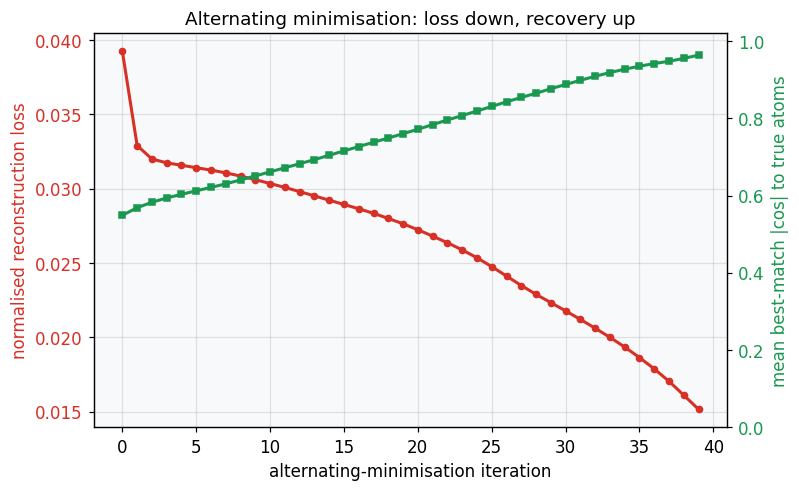

In [4]:
fig, ax1 = plt.subplots(figsize=(7.4, 4.6))
ax1.plot(losses, 'o-', color='#d73027', lw=2, ms=4, label='reconstruction loss')
ax1.set_xlabel('alternating-minimisation iteration')
ax1.set_ylabel('normalised reconstruction loss', color='#d73027')
ax1.tick_params(axis='y', labelcolor='#d73027')
ax2 = ax1.twinx()
ax2.plot(recoveries, 's-', color='#1a9850', lw=2, ms=4, label='atom recovery')
ax2.set_ylabel('mean best-match |cos| to true atoms', color='#1a9850')
ax2.tick_params(axis='y', labelcolor='#1a9850'); ax2.grid(False); ax2.set_ylim(0, 1.02)
ax1.set_title('Alternating minimisation: loss down, recovery up')
plt.tight_layout(); plt.show()

### What you see

Each round the reconstruction loss falls (red) while atom recovery climbs toward 1 (green): from a
random start, alternating between ISTA coding and MOD updates **reconstructs the planted dictionary**.
Neither step alone could — it is the back-and-forth that works, exactly the structure the note
describes. This is the classical (non-amortised) route: an explicit optimisation, not a learned
encoder.

## Experiment 2: ISTA — sparse coding by soft-thresholding

**Question:** How does the inner sparse-coding solve actually reach a sparse code?

With the dictionary fixed to `D_true`, we watch ISTA solve for the codes of a batch: the soft-threshold
operator drives small coefficients to exactly zero each step, so the code's L0 (active count) shrinks
toward the true $k=3$ while reconstruction stays faithful.

In [5]:
Xb = X[:, :500]
D = D_true
eta = 1.0 / (np.linalg.norm(D, 2) ** 2)
lam = 0.1
A = np.zeros((m, Xb.shape[1]))
L0_curve, err_curve = [], []
for t in range(120):
    A = soft(A + eta * D.T @ (Xb - D @ A), lam * eta)
    L0_curve.append((np.abs(A) > 1e-4).sum(0).mean())
    err_curve.append(np.linalg.norm(Xb - D @ A) / np.linalg.norm(Xb))
print(f'true sparsity k = {k};  ISTA final mean L0 = {L0_curve[-1]:.1f}')

true sparsity k = 3;  ISTA final mean L0 = 4.0


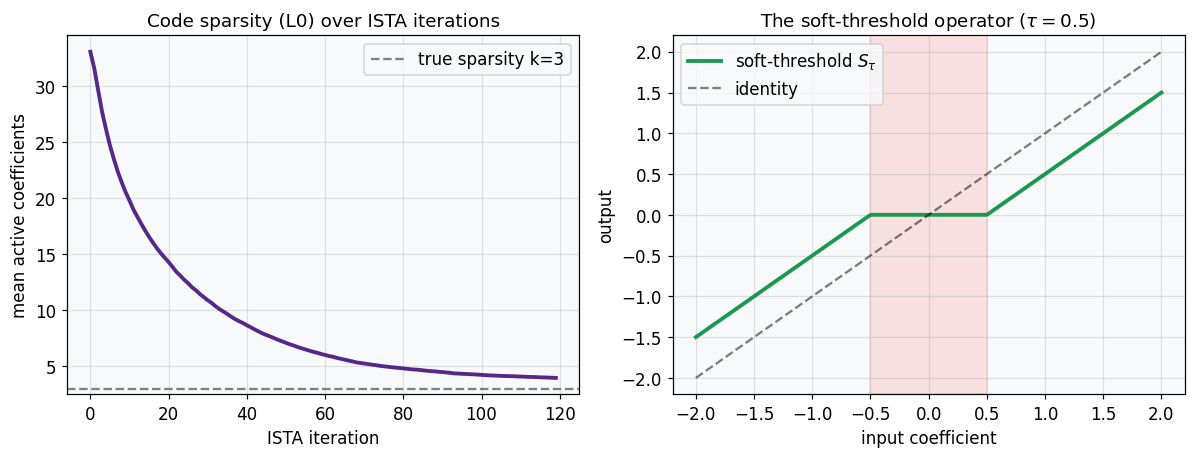

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(L0_curve, color='#542788', lw=2.5)
axes[0].axhline(k, color='gray', ls='--', label=f'true sparsity k={k}')
axes[0].set_title('Code sparsity (L0) over ISTA iterations')
axes[0].set_xlabel('ISTA iteration'); axes[0].set_ylabel('mean active coefficients'); axes[0].legend()
zz = np.linspace(-2, 2, 400)
axes[1].plot(zz, soft(zz, 0.5), color='#1a9850', lw=2.5, label=r'soft-threshold $S_\tau$')
axes[1].plot(zz, zz, 'k--', alpha=0.5, label='identity')
axes[1].axvspan(-0.5, 0.5, color='red', alpha=0.1)
axes[1].set_title('The soft-threshold operator ($\\tau=0.5$)')
axes[1].set_xlabel('input coefficient'); axes[1].set_ylabel('output'); axes[1].legend()
plt.tight_layout(); plt.show()

### What you see

Left: ISTA starts dense and the active-coefficient count **falls toward the true $k=3$** as the
soft-threshold repeatedly zeroes out small entries — the code becomes sparse over iterations. Right:
the soft-threshold operator $\mathcal{S}_\tau$ kills everything in the red band $|z|<\tau$ (creating
exact zeros) and **shrinks** what survives toward zero (the line sits below identity). That shrinkage
is harmless for finding support here, but — as the next experiment shows — it biases the recovered
magnitudes.

## Experiment 3: $\ell_0$ (OMP) vs $\ell_1$ (ISTA) — shrinkage again

**Question:** Does the $\ell_1$ relaxation distort the recovered magnitudes?

We solve the same sparse-coding problem two ways with `D_true`: **OMP** (greedy $\ell_0$, picks exactly
$k$ atoms, no penalty on size) and **ISTA** ($\ell_1$). We then plot each method's recovered magnitudes
against the true code values.

In [7]:
Xb = X[:, :800]
A_omp = orthogonal_mp(D_true, Xb, n_nonzero_coefs=k)        # l0 greedy
A_ista = ista(Xb, D_true, lam=0.3, n_iter=400)             # l1
mask = A_true[:, :800] > 1e-6                               # true active entries
t_vals = A_true[:, :800][mask]
omp_vals = A_omp[mask]
ista_vals = A_ista[mask]
bias_omp = float((omp_vals - t_vals).mean())               # additive magnitude bias
bias_ista = float((ista_vals - t_vals).mean())
print(f'OMP  (l0) mean magnitude bias = {bias_omp:+.3f}')
print(f'ISTA (l1) mean magnitude bias = {bias_ista:+.3f}  (<0 => shrinkage)')

OMP  (l0) mean magnitude bias = -0.052
ISTA (l1) mean magnitude bias = -0.339  (<0 => shrinkage)


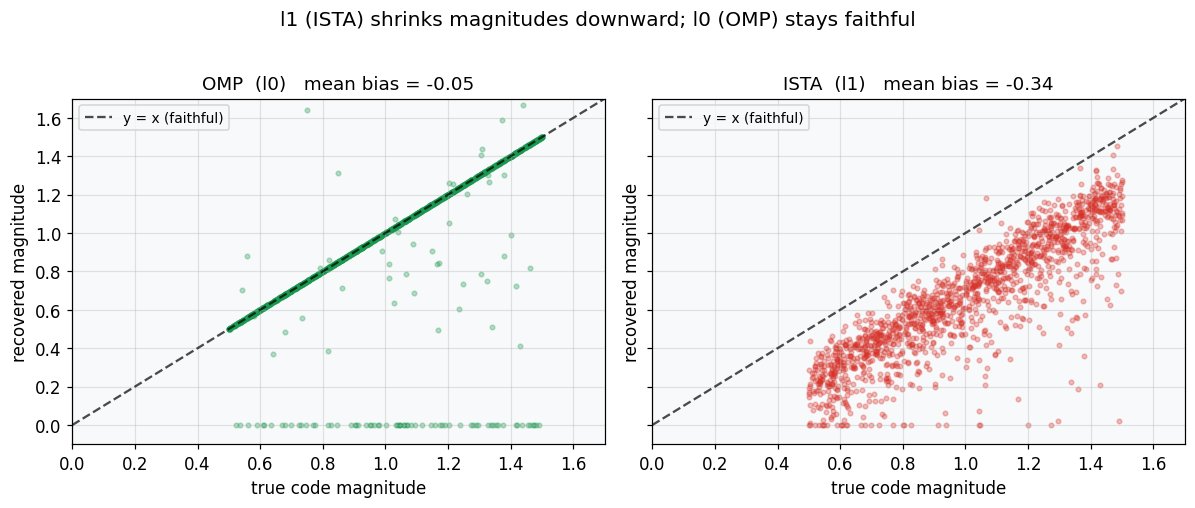

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, vals, bias, title, col in [(axes[0], omp_vals, bias_omp, 'OMP  (l0)', '#1a9850'),
                                   (axes[1], ista_vals, bias_ista, 'ISTA  (l1)', '#d73027')]:
    idx = np.random.RandomState(0).choice(len(t_vals), min(1500, len(t_vals)), replace=False)
    ax.scatter(t_vals[idx], vals[idx], s=9, alpha=0.3, color=col)
    lim = [0, 1.7]
    ax.plot(lim, lim, 'k--', alpha=0.7, label='y = x (faithful)')
    ax.set_title(f'{title}   mean bias = {bias:+.2f}')
    ax.set_xlabel('true code magnitude'); ax.set_ylabel('recovered magnitude')
    ax.set_xlim(lim); ax.set_ylim(-0.1, 1.7); ax.legend(fontsize=9, loc='upper left')
fig.suptitle('l1 (ISTA) shrinks magnitudes downward; l0 (OMP) stays faithful', y=1.02)
plt.tight_layout(); plt.show()

### What you see

OMP ($\ell_0$) lands on the diagonal — it selects atoms and estimates magnitudes faithfully (mean bias
$\approx-0.05$, essentially zero). The ISTA ($\ell_1$) cloud sits **below** the diagonal, shifted down
roughly in *parallel* (mean bias $\approx-0.34$): soft-thresholding subtracts a near-constant amount
from every coefficient — an **additive shrinkage** set by $\lambda$.

This is the *same* trade that separates **TopK** from **L1** SAEs in
[the SAE notebook](07_sparse_autoencoder.ipynb) — and it is no coincidence: TopK is the amortised echo
of $\ell_0$/OMP, and L1 SAEs inherit ISTA's shrinkage. The SAE design choices are dictionary-learning
choices in disguise.

## Experiment 4: SAE = amortised dictionary learning (the amortisation gap)

**Question:** What exactly does an SAE trade away for speed?

We fix the dictionary to `D_true` and compare two ways to get codes for *unseen* inputs: the optimal
**ISTA** solve (iterative) versus a single-layer **encoder** $a=\mathrm{ReLU}(W_\text{enc}x+b)$ trained
to predict codes (amortised, one forward pass). We compare reconstruction quality and speed.

In [9]:
A_tr = make_codes(4000, 10); X_tr = torch.tensor((D_true @ A_tr).T, dtype=torch.float32)   # train
A_te = make_codes(1500, 11); X_te_np = D_true @ A_te; X_te = torch.tensor(X_te_np.T, dtype=torch.float32)
Dt = torch.tensor(D_true, dtype=torch.float32)

# train an amortised encoder to predict codes (dictionary fixed to D_true)
W_enc = nn.Parameter(torch.randn(m, d) * 0.1); b_enc = nn.Parameter(torch.zeros(m))
opt = torch.optim.Adam([W_enc, b_enc], lr=5e-3)
for _ in range(3000):
    a = torch.relu(X_tr @ W_enc.t() + b_enc)
    recon = a @ Dt.t()
    loss = ((X_tr - recon) ** 2).sum(1).mean() + 0.1 * a.abs().sum(1).mean()
    opt.zero_grad(); loss.backward(); opt.step()

# inference on test set: encoder (1 forward) vs ISTA (iterative)
t0 = time.perf_counter()
with torch.no_grad():
    a_sae = torch.relu(X_te @ W_enc.t() + b_enc).numpy().T          # (m, n_test)
t_sae = time.perf_counter() - t0
t0 = time.perf_counter()
a_ista = ista(X_te_np, D_true, lam=0.1, n_iter=300)
t_ista = time.perf_counter() - t0

def nerr(A):
    return np.linalg.norm(X_te_np - D_true @ A) ** 2 / np.linalg.norm(X_te_np) ** 2
err_sae, err_ista = nerr(a_sae), nerr(a_ista)
print(f'ISTA  : recon-err={err_ista:.4f}   time={t_ista*1e3:.0f} ms')
print(f'SAE   : recon-err={err_sae:.4f}   time={t_sae*1e3:.0f} ms')
print(f'amortisation gap = {err_sae - err_ista:.4f};   speedup = {t_ista/max(t_sae,1e-6):.0f}x')

ISTA  : recon-err=0.0100   time=501 ms
SAE   : recon-err=0.0652   time=1 ms
amortisation gap = 0.0552;   speedup = 431x


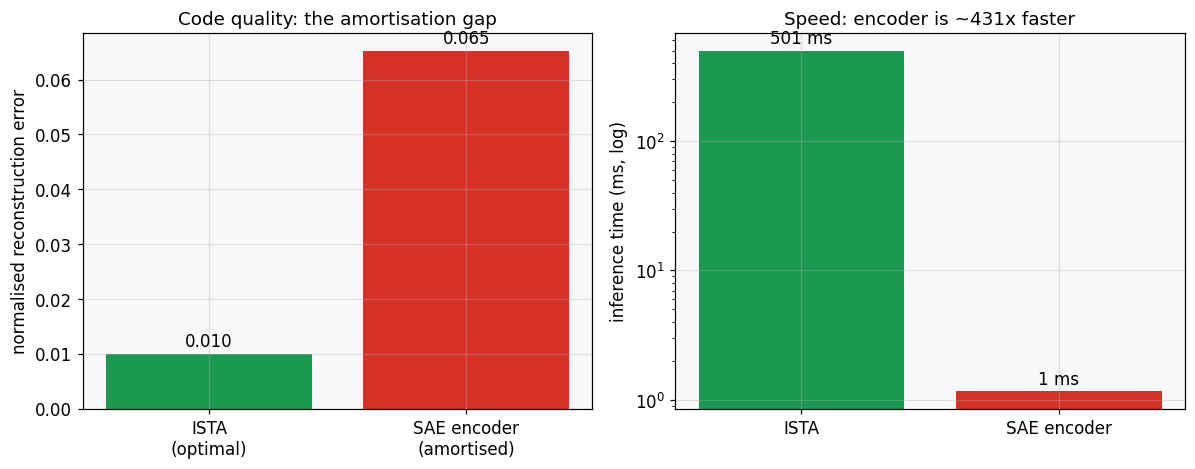

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].bar(['ISTA\n(optimal)', 'SAE encoder\n(amortised)'], [err_ista, err_sae],
            color=['#1a9850', '#d73027'])
axes[0].set_ylabel('normalised reconstruction error')
axes[0].set_title('Code quality: the amortisation gap')
for i, v in enumerate([err_ista, err_sae]):
    axes[0].annotate(f'{v:.3f}', (i, v), textcoords='offset points', xytext=(0, 5), ha='center')
axes[1].bar(['ISTA', 'SAE encoder'], [t_ista * 1e3, t_sae * 1e3], color=['#1a9850', '#d73027'])
axes[1].set_ylabel('inference time (ms, log)'); axes[1].set_yscale('log')
axes[1].set_title(f'Speed: encoder is ~{t_ista/max(t_sae,1e-6):.0f}x faster')
for i, v in enumerate([t_ista * 1e3, t_sae * 1e3]):
    axes[1].annotate(f'{v:.0f} ms', (i, v), textcoords='offset points', xytext=(0, 5), ha='center')
plt.tight_layout(); plt.show()

### What you see

The amortised encoder reconstructs **clearly worse** than the optimal ISTA solve (here several times
the error) — that residual is the **amortisation gap**: a single feed-forward pass cannot match an
iterative optimiser's code. But it is **orders of magnitude faster**, because it replaces the
whole ISTA loop with one matrix multiply.

This *is* what an SAE is: dictionary learning with the per-sample sparse-coding optimisation replaced
by a learned encoder. The gap is the price; the speed (and scalability to billions of activations) is
why interpretability at LLM scale uses SAEs rather than K-SVD.

## Experiment 5 (limitation): non-convexity and local minima

**Question:** Is the recovered dictionary unique?

The joint objective is convex in $D$ *or* in the codes, but **not in both** — it is non-convex. We run
alternating minimisation from several random initialisations and look at where they land.

In [11]:
final_loss, final_recov = [], []
for seed in range(12):
    r = np.random.RandomState(100 + seed)
    Dr = r.randn(d, m); Dr /= np.linalg.norm(Dr, axis=0, keepdims=True)
    for _ in range(30):
        A = ista(X, Dr, lam=0.1, n_iter=60)
        Dr = X @ A.T @ np.linalg.inv(A @ A.T + 1e-6 * np.eye(m))
        Dr /= np.linalg.norm(Dr, axis=0, keepdims=True) + 1e-9
    final_loss.append(np.linalg.norm(X - Dr @ A) ** 2 / np.linalg.norm(X) ** 2)
    final_recov.append(best_recovery(Dr, D_true))
final_loss, final_recov = np.array(final_loss), np.array(final_recov)
print(f'recovery across 12 inits: min={final_recov.min():.3f}  max={final_recov.max():.3f}  std={final_recov.std():.3f}')

recovery across 12 inits: min=0.773  max=0.900  std=0.046


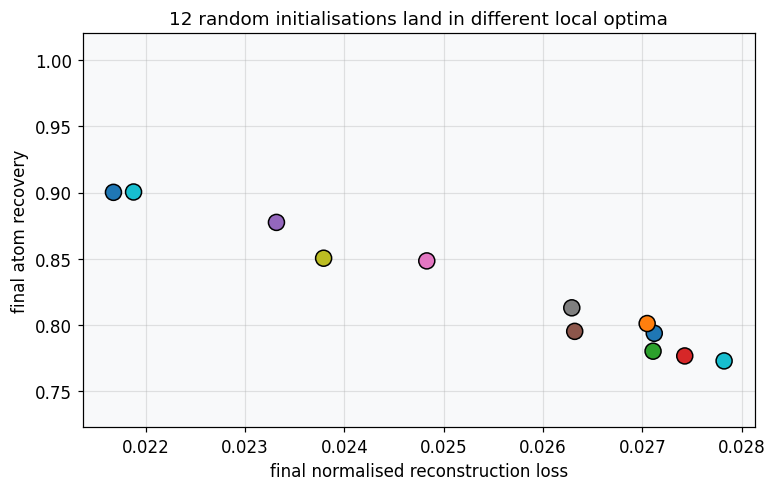

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
sc = ax.scatter(final_loss, final_recov, s=110, c=range(12), cmap='tab10', edgecolor='k', zorder=3)
ax.set_xlabel('final normalised reconstruction loss')
ax.set_ylabel('final atom recovery')
ax.set_title('12 random initialisations land in different local optima')
ax.set_ylim(min(final_recov) - 0.05, 1.02)
plt.tight_layout(); plt.show()

### What you see

The twelve runs do **not** all reach the same place: final recovery (and loss) **varies across
initialisations** — some runs recover the dictionary cleanly, others get stuck in inferior local
optima. Alternating minimisation only guarantees a *local* optimum of a non-convex objective.

This is the note's core limitation, and it carries over to SAEs (different seeds learn different
dictionaries) and underlies the **non-canonical** caveat: there is no single dictionary the method is
guaranteed to find, so a recovered basis is one valid decomposition among many — to be validated by
[causal intervention](../research/04-causal-intervention-vs-observational.md), not taken as ground
truth.

## Summary / Key Takeaways

- **Exp 1** — **Alternating minimisation** (ISTA coding + MOD updates) recovers a planted dictionary from
  data alone — the classical, non-amortised route.
- **Exp 2** — **ISTA** reaches a sparse code by iterated **soft-thresholding**, which zeroes small
  coefficients and shrinks the rest.
- **Exp 3** — $\ell_0$ (OMP) recovers magnitudes faithfully; $\ell_1$ (ISTA) **shrinks** them by a
  near-constant amount — the same trade as TopK vs L1 SAEs.
- **Exp 4** — An **SAE is amortised dictionary learning**: a feed-forward encoder is far faster than
  ISTA but leaves an **amortisation gap** in code quality.
- **Exp 5** — The objective is **non-convex**: different initialisations reach different dictionaries,
  the root of the non-canonical caveat.
